Evan Edelstein
EN.605.645.82.SP26

# Module 12 - Programming Assignment

## General Directions

1. You must follow the Programming Requirements outlined on Canvas.
2. The Notebook should be cleanly and fully executed before submission.
3. You should change the name of this file to be your JHED id. For example, `jsmith299.ipynb` although Canvas will change it to something else...
4. You must follow the Programming Requirments for this course.

<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Important</strong>
    <p>
        You should always read the entire assignment before beginning your work, so that you know in advance what the requested output will be and can plan your implementation accordingly.
    </p>
</div>

<div style="color: white; background: #C83F49; margin:20px; padding: 20px;">
    <strong>Academic Integrity and Copyright</strong>
    <p>You are not permitted to consult outside sources (Stackoverflow, YouTube, ChatGPT, etc.) or use "code assistance" (Co-Pilot, etc) to complete this assignment. By submitting this assignment for grading, you certify that the submission is 100% your own work, based on course materials, group interactions, instructor guidance. You agree to comply by the requirements set forth in the Syllabus, including, by reference, the JHU KSAS/WSE Graduate Academic Misconduct Policy.</p>
    <p>Sharing this assignment either directly (e.g., email, github, homework site) or indirectly (e.g., ChatGPT, machine learning platform) is a violation of the copyright. Additionally, all such sharing is a violation the Graduate Academic Misconduct Policy (facilitating academic dishonesty is itself academic dishonesty), even after you graduate.</p>
    <p>If you have questions or if you're unsure about the policy, ask via Canvas Inbox. In this case, being forgiven is <strong>not</strong> easier than getting permission and ignorance is not an excuse.</p>
    <p>This assignment is copyright (&copy Johns Hopkins University &amp; Stephyn G. W. Butcher). All rights reserved.</p>
</div>

## k Nearest Neighbors and Model Evaluation

In this programming assignment you will use k Nearest Neighbors (kNN) to build a "model" that will estimate the compressive strength of various types of concrete. This assignment has several objectives:

1. Implement the kNN algorithm with k=9. Remember...the data + distance function is the model in kNN. In addition to asserts that unit test your code, you should "test drive" the model, showing output that a non-technical person could interpret.

2. You are going to compare the kNN model above against the baseline model described in the course notes (the mean of the training set's target variable). You should use 10 fold cross validation and Mean Squared Error (MSE):

$$MSE = \frac{1}{n}\sum^n_i (y_i - \hat{y}_i)^2$$

as the evaluation metric ("error"). Refer to the course notes for the format your output should take. Don't forget a discussion of the results.

3. use validation curves to tune a *hyperparameter* of the model. 
In this case, the hyperparameter is *k*, the number of neighbors. Don't forget a discussion of the results.

4. evaluate the *generalization error* of the new model.
Because you may have just created a new, better model, you need a sense of its generalization error, calculate that. Again, what would you like to see as output here? Refer to the course notes. Don't forget a discussion of the results. Did the new model do better than either model in Q2?

5. pick one of the "Choose Your Own Adventure" options.

Refer to the "course notes" for this module for most of this assignment.
Anytime you just need test/train split, use fold index 0 for the test set and the remainder as the training set.
Discuss any results.

## Load the Data

The function `parse_data` loads the data from the specified file and returns a List of Lists. The outer List is the data set and each element (List) is a specific observation. Each value of an observation is for a particular measurement. This is what we mean by "tidy" data.

The function also returns the *shuffled* data because the data might have been collected in a particular order that *might* bias training.

In [1]:
import random
from typing import List, Dict, Tuple, Callable, NamedTuple
from math import sqrt, inf
import matplotlib.pyplot as plt
from copy import deepcopy

In [2]:
def parse_data(file_name: str) -> List[List]:
    data = []
    file = open(file_name, "r")
    for line in file:
        datum = [float(value) for value in line.rstrip().split(",")]
        data.append(datum)
    random.shuffle(data)
    return data

In [3]:
concrete_dataset = parse_data("concrete_compressive_strength-3.csv")

In [4]:
concrete_dataset[0]

[281.0, 0.0, 0.0, 186.0, 0.0, 1104.0, 774.0, 7.0, 14.5]

In [5]:
len(concrete_dataset)

1030

There are 1,030 observations and each observation has 8 measurements. The data dictionary for this data set tells us the definitions of the individual variables (columns/indices):

| Index | Variable | Definition |
|-------|----------|------------|
| 0     | cement   | kg in a cubic meter mixture |
| 1     | slag     | kg in a cubic meter mixture |
| 2     | ash      | kg in a cubic meter mixture |
| 3     | water    | kg in a cubic meter mixture |
| 4     | superplasticizer | kg in a cubic meter mixture |
| 5     | coarse aggregate | kg in a cubic meter mixture |
| 6     | fine aggregate | kg in a cubic meter mixture |
| 7     | age | days |
| 8     | concrete compressive strength | MPa |

The target ("y") variable is a Index 8, concrete compressive strength in (Mega?) [Pascals](https://en.wikipedia.org/wiki/Pascal_(unit)).

## Train/Test Splits - n folds

With n fold cross validation, we divide our data set into n subgroups called "folds" and then use those folds for training and testing. You pick n based on the size of your data set. If you have a small data set--100 observations--and you used n=10, each fold would only have 10 observations. That's probably too small. You want at least 30. At the other extreme, we generally don't use n > 10.

With 1,030 observations, n = 10 is fine so we will have 10 folds.
`create_folds` will take a list (xs) and split it into `n` equal folds with each fold containing one-tenth of the observations.

In [6]:
def create_folds(xs: List, n: int) -> List[List[List]]:
    k, m = divmod(len(xs), n)
    # be careful of generators...
    return list(xs[i * k + min(i, m) : (i + 1) * k + min(i + 1, m)] for i in range(n))

In [7]:
folds = create_folds(concrete_dataset, 10)

In [8]:
len(folds)

10

We always use one of the n folds as a test set (and, sometimes, one of the folds as a *pruning* set but not for kNN), and the remaining folds as a training set.
We need a function that'll take our n folds and return the train and test sets:

In [9]:
def create_train_test(folds: List[List[List]], index: int) -> Tuple[List[List], List[List]]:
    training = []
    test = []
    for i, fold in enumerate(folds):
        if i == index:
            test = fold
        else:
            training = training + fold
    return training, test

We can test the function to give us a train and test datasets where the test set is the fold at index 0:

In [10]:
train, test = create_train_test(folds, 0)

In [11]:
len(train)

927

In [12]:
len(test)

103

## Answers

Answer the questions above in the space provided below, adding cells as you need to.
Put everything in the helper functions and document them.
Document everything (what you're doing and why).
If you're not sure what format the output should take, refer to the course notes and what they do for that particular topic/algorithm.

## Problem 1: kNN

Implement k Nearest Neighbors algorithm with k = 9. (Do not confuse the algorithm with evaluating the algorithm. We just want the algorithm here.)

<a id="average_label"></a>
## average_label

*`average_label` Given a list of tuples containing the distance from the query point and the list of features, and the position of the label in the feature list, calculate the average label value.* **Used by**: [knn](#knn)

* **nearest** List[Tuple[float, List[float]]]: list of tuples containing the distance from the query point and the list of features
* **label_idx** int: label position in feature list


**returns** float - average label value

In [13]:
def average_label(nearest: List[Tuple[float, List[float]]], label_idx: int) -> float | None:
    if not nearest:
        return None

    valid_neighbors = [example[label_idx] for dist, example in nearest if dist is not None]
    if not valid_neighbors:
        return None
    return sum(valid_neighbors) / len(valid_neighbors)

In [14]:
data = [(0.24, [0.23, 0.81, 0.18]), (0.15, [0.42, 0.78, 0.33]), (0.47, [0.64, 0.23, 0.14]), (0.65, [0.87, 0.19, 0.17]), (0.42, [0.76, 0.43, 0.32])]
result = average_label(data, 2)
assert result is not None and round(result, 3) == 0.228  # test 1 - average of last column

data = []
result = average_label(data, 2)
assert result is None  # test 3 - empty data returns None

data = [(None, [])]
result = average_label(data, 2)
assert result is None  # test 3 - if all neighbors have None distances, None is returned


<a id="euclidean_distance"></a>
## euclidean_distance

*`euclidean_distance` Calculate the Euclidean Distance between 2 vectors, ignoring the values at the label position. The Euclidean Distance is given by: $$ d(x,y) = \sqrt{\sum_i{(|x_i -y_i|^2)}} $$* **Used by**: [knn](#knn)

* **example** List[float]: list of feature values
* **query** List[float]: list of feature values
* **label_idx** int: label position in feature list


**returns** float | None - distance from example to query or None if example or query is empty

In [15]:
def euclidean_distance(example: List[float], query: List[float], label_idx: int) -> float | None:
    if not example or not query:
        return None
    distance = sum([(x - y) ** 2 for i, (x, y) in enumerate(zip(example, query)) if i != label_idx])
    return sqrt(distance)

In [16]:
data = [(0.24, [0.23, 0.81, 0.18]), (0.15, [0.42, 0.78, 0.33]), (0.47, [0.64, 0.23, 0.14]), (0.65, [0.87, 0.19, 0.17]), (0.42, [0.76, 0.43, 0.32])]

query = [0.39, 0.63]

result = euclidean_distance(data[0][1], query, 2)
assert result is not None and round(result, 3) == 0.241  # test 1 - distance with first example


result = euclidean_distance([], query, 2)
assert result is None  # test 2 - empty example returns None

result = euclidean_distance(query, query, 2)
assert result == 0.0  # test 3 - distance btw query and query is 0.0

<a id="pretty_print_distances"></a>
## pretty_print_distances

*`pretty_print_distances` Given a list of tuples containing the distance from the query point and the list of features, and the k cutoff, pretty print the features and distance of the dataset.* **Used by**: [knn](#knn)

* **distances** List[Tuple[float| None, List[float]]]: list of tuples containing the distance from the query point and the list of features
* **k** int: number of neighbors to include in prediction




In [17]:
def pretty_print_distances(distances: List[Tuple[float, List[float]]], k: int):
    print("fold\tExample\tDistance")
    for i, (dist, example) in enumerate(distances):
        if k > 0 and i == k:
            print("-----" * 10)
        print(f"{i}\t{example}\t{dist}")
    print()
    return

In [18]:
data = [(0.24, [0.23, 0.81, 0.18]), (0.15, [0.42, 0.78, 0.33]), (0.47, [0.64, 0.23, 0.14]), (0.65, [0.87, 0.19, 0.17]), (0.42, [0.76, 0.43, 0.32])]

pretty_print_distances(data, 0)  # test 1 - k = 0
pretty_print_distances(data, -1)  # test 2 - k less than zero still prints data
data = []
pretty_print_distances(data, -1)  # test 3 - empty input prints nothing


fold	Example	Distance
0	[0.23, 0.81, 0.18]	0.24
1	[0.42, 0.78, 0.33]	0.15
2	[0.64, 0.23, 0.14]	0.47
3	[0.87, 0.19, 0.17]	0.65
4	[0.76, 0.43, 0.32]	0.42

fold	Example	Distance
0	[0.23, 0.81, 0.18]	0.24
1	[0.42, 0.78, 0.33]	0.15
2	[0.64, 0.23, 0.14]	0.47
3	[0.87, 0.19, 0.17]	0.65
4	[0.76, 0.43, 0.32]	0.42

fold	Example	Distance



<a id="knn"></a>
## knn

*`knn` Given a list of feature rows, a query vector, the number of neighbors to consider (k), the position of the label value in the row, a distance function and a processing function, find the k closest rows to query by the distance function and produce a result with the processing function.* **Uses** [euclidean_distance](#euclidean_distance), [average_label](#average_label) and [pretty_print_distances](#pretty_print_distances)

* **dataset** List[List[float]]: list of rows each of which is a list of features values
* **query** List[float]: list of feature values
* **k** int: number of neighbors to include in prediction
* **label_idx** int: label position in feature list
* **distance** Callable: function to calculate distance between rows
* **processing** Callable: function to process k nearest rows
* **debug** bool: if true print the neighbors

**returns** float: the result of processing the k nearest neighbors.

In [19]:
def knn(
    dataset: List[List[float]], query: List[float], k: int, label_idx: int, distance: Callable = euclidean_distance, processing: Callable = average_label, debug: bool = False
) -> float | None:
    distances = [(distance(example, query, label_idx), example) for example in dataset]
    distances = sorted(distances, key=lambda x: (x[0] is None, x[0]))
    pretty_print_distances(distances, k) if debug else None
    return processing(distances[:k], label_idx)

In [ ]:
data = [[0.23, 0.81, 0.18], [0.42, 0.78, 0.33], [0.64, 0.23, 0.14], [0.87, 0.19, 0.17], [0.76, 0.43, 0.32]]
query = [0.39, 0.63]

result = knn(data, query, 3, 2)
assert result is not None and round(result, 2) == 0.28  # test 1 - average label from top 3 neighbors


data = []
query = [0.39, 0.63]

result = knn(data, query, 1, 2)
assert result is None  # test 2 - empty data returns None


data = [[0.23, 0.81, 0.18], [], [0.64, 0.23, 0.14], [0.87, 0.19, 0.17], [0.76, 0.43, 0.32]]
query = [0.39, 0.63]

result = knn(data, query, 1, 2)
assert result is not None and result == 0.18  # test 3 - Missing row is skipped

<a id="print_features"></a>
## print_features

*`print_features` Given a list of feature rows, and a list of tuples representing the name of feature and its unit, print each value with the appropriate name and unit.*

* **query** List[float]: list of feature values
* **dataset** List[Tuple[str, str]]: list of tuples with the name and unit of each feature

In [21]:
def print_features(values: List[float], feature_names: List[Tuple[str, str]]):
    for val, (name, unit) in zip(values, feature_names):
        print(f"{name}: {val} {unit}")

In [22]:
k = 9
label = 8
query = test[0]
feature_names = [
    ("Cement", "kg"),
    ("Slag", "kg"),
    ("Ash", "kg"),
    ("Water", "kg"),
    ("Superplasticizer", "kg"),
    ("Coarse aggregate", "kg"),
    ("Fine aggregate", "kg"),
    ("Age", "days"),
]
result = knn(train, query, k, label)
print("Input:")
print_features(query, feature_names)
print()
print(f"Predicted Concrete Strength (k={k}):")
print(f"{result:.3f} | Actual: {query[label]:.3f}")

Input:
Cement: 281.0 kg
Slag: 0.0 kg
Ash: 0.0 kg
Water: 186.0 kg
Superplasticizer: 0.0 kg
Coarse aggregate: 1104.0 kg
Fine aggregate: 774.0 kg
Age: 7.0 days

Predicted Concrete Strength (k=9):
18.024 | Actual: 14.500


In [23]:
for i, val in enumerate(query):
    if i == label:
        continue
    print(f"{feature_names[i][0]}:")
    adjusted_query = deepcopy(query)
    adjusted_query[i] = val + 100
    result = knn(train, adjusted_query, k, label)
    print(f"Adjusting {feature_names[i][0]} by +100")
    print(f"Predicted Concrete Strength (k={k}):")
    print(f"{result:.3f} | Actual: {adjusted_query[label]:.3f}")

    adjusted_query  = deepcopy(query)
    adjusted_query[i] = val - 100
    result = knn(train, adjusted_query, k, label)
    print(f"Adjusting {feature_names[i][0]} by -100")
    print(f"Predicted Concrete Strength (k={k}):")
    print(f"{result:.3f} | Actual: {adjusted_query[label]:.3f}")
    print()

Cement:
Adjusting Cement by +100
Predicted Concrete Strength (k=9):
23.588 | Actual: 14.500
Adjusting Cement by -100
Predicted Concrete Strength (k=9):
14.567 | Actual: 14.500

Slag:
Adjusting Slag by +100
Predicted Concrete Strength (k=9):
41.031 | Actual: 14.500
Adjusting Slag by -100
Predicted Concrete Strength (k=9):
18.024 | Actual: 14.500

Ash:
Adjusting Ash by +100
Predicted Concrete Strength (k=9):
31.143 | Actual: 14.500
Adjusting Ash by -100
Predicted Concrete Strength (k=9):
18.024 | Actual: 14.500

Water:
Adjusting Water by +100
Predicted Concrete Strength (k=9):
18.024 | Actual: 14.500
Adjusting Water by -100
Predicted Concrete Strength (k=9):
17.798 | Actual: 14.500

Superplasticizer:
Adjusting Superplasticizer by +100
Predicted Concrete Strength (k=9):
18.024 | Actual: 14.500
Adjusting Superplasticizer by -100
Predicted Concrete Strength (k=9):
18.024 | Actual: 14.500

Coarse aggregate:
Adjusting Coarse aggregate by +100
Predicted Concrete Strength (k=9):
15.522 | Actual

## Problem 2: Evaluation vs. The Mean

Using Mean Squared Error (MSE) as your evaluation metric, evaluate your implement above and the Null model, the mean. See the notes for the format of the output.

For this part of the assignment, the Programming Requirements are a bit difficult (although not impossible) to follow in terms of *testing*. If you can figure out how to test your code, that's best but if you can't, for this part of the assignment, that's ok.

<a id="mean_model"></a>
## mean_model

*`mean_model` Given a list of feature rows, a query vector, the number of neighbors to consider (k), the position of the label value in the row, return the mean of the label value.*

* **dataset** List[List[float]]: list of rows each of which is a list of features values
* **query** List[float]: list of feature values
* **k** int: number of neighbors to include in prediction
* **label_idx** int: label position in feature list

*returns* float | None - mean of label value or None if input in empty 

In [24]:
def mean_model(dataset: List[List[float]], query: List[float], k: int, label_idx: int) -> float | None:
    if not any(dataset):
        return None

    valid_neighbors = [row[label_idx] for row in dataset if 0 <= label_idx < len(row)]
    if not valid_neighbors:
        return None
    return sum(valid_neighbors) / len(valid_neighbors)

In [ ]:
data = [[0.23, 0.81, 0.18], [0.42, 0.78, 0.33], [0.64, 0.23, 0.14], [0.87, 0.19, 0.17], [0.76, 0.43, 0.32]]
query = [0.39, 0.63]

result = mean_model(data, query, 3, 2)
assert result is not None and round(result, 2) == 0.23  # test 1 - average label


data = []
query = [0.39, 0.63]

result = mean_model(data, query, 1, 2)
assert result is None  # test 2 - empty data returns None

data = [[0.23, 0.81, 0.18], [], [0.64, 0.23, 0.14], [0.87, 0.19, 0.17], [0.76, 0.43, 0.32]]
query = [0.39, 0.63]

result = mean_model(data, query, 1, 2)
assert result is not None and round(result, 2) == 0.20  # test 3 - Missing row is skipped

<a id="evaluate"></a>
## evaluate

*`evaluate` Given a test set (list of feature rows), a training set, a label position in the feature vector and number of neighbors to consider and a predictor (knn by default), calculate the Mean Squared Error of running the predictor on the each observation in the test set. Mean Squared Error is defined as: $$\frac{1}{n} \sum_i^n{(y_i - \hat{y}_i)^2}$$ for actual label $y$ and predicted label $\hat{y}$ .* **Uses** [knn](#knn)

* **train** List[float]: list of rows each of which is a list of features values to train on
* **test** List[List[float]]: list of rows each of which is a list of features values to test against
* **label_idx** int: label position in feature list
* **k** int: number of neighbors to include in prediction
* **predictor**: Callable: function to predict query from training data

**returns** float | None -  MSE of model or none if input is empty 

In [26]:
def evaluate(train: List[List[float]], test: List[List[float]], k: int, label_idx: int, predictor: Callable = knn) -> float | None:
    squared_error = 0

    if not len(test) or not len(train):
        return None
    
    test_size = 0
    for query in test:
        if not (0 <= label_idx < len(query)):
            continue
        
        result = predictor(train, query, k, label_idx)
        if result is not None:
            squared_error += (query[label_idx] - result) ** 2
            test_size +=1
    if test_size == 0:
        return None
    return squared_error / test_size

In [ ]:
data = [[0.23, 0.81, 0.18], [0.42, 0.78, 0.33], [0.64, 0.23, 0.14], [0.87, 0.19, 0.17]]
query = [[0.76, 0.43, 0.32]]

result = evaluate(data, query, 3, 2)
assert result is not None and round(result, 2) == 0.01  # test 1 - MSE of last column


data = []
query = [[0.76, 0.43, 0.32]]

result = evaluate(data, query, 1, 2)
assert result is None  # test 2 - empty data returns None

data = [[0.23, 0.81, 0.18], [], [0.64, 0.23, 0.14], [0.87, 0.19, 0.17]]
query = [[0.76, 0.43, 0.32]]

result = evaluate(data, query, 1, 2)
assert result is not None and round(result, 2) == 0.03  # test 3 - Missing row is skipped

<a id="cross_validate"></a>
## cross_validate

*`cross_validate` Perform n-fold cross validation on a dataset using kNN to generate predictions and MSE as an error metrics.* **Uses** [evaluate](#evaluate)

* **dataset** List[List[float]]: list of rows each of which is a list of features values 
* **k** int: number of neighbors to include in prediction
* **label_idx** int: label position in feature list
* **n_folds** int: number of folds to cross validate on


**returns** List[Tuple[float, float]]: mean squared error and average label value of each fold 

In [28]:
def cross_validate(dataset: List[List[float]], k: int, label_idx: int, n_folds: int = 10, normalize: Callable | None = None) -> List[Tuple[float, float]]:
    folds = create_folds(dataset, n_folds)
    result = []
    
    for i in range(n_folds):
        train, test = create_train_test(folds, i)
        if normalize is not None:
            train, test = normalize(train, test, label_idx)

        knn_mse = evaluate(train, test, k, label_idx, knn)
        mean_mse = evaluate(train, test, k, label_idx, mean_model)
        if knn_mse is None or mean_mse is None:
            continue
        result.append((knn_mse, mean_mse))
    return result

In [29]:
data = [[0.23, 0.81, 0.18], [0.42, 0.78, 0.33], [0.64, 0.23, 0.14], [0.87, 0.19, 0.17], [0.76, 0.43, 0.32]]

result = cross_validate(data, 2, 2, 2)
assert round(result[0][0], 2) == 0.01 and round(result[0][1], 2) == 0.01 and round(result[1][0], 2) == 0.01 and round(result[1][1], 2) == 0.01


data = []
query = [[0.76, 0.43, 0.32]]

result = cross_validate(data, 2, 2, 2)
assert result == []  # test 2 - empty data returns empty result

data = [[0.23, 0.81, 0.18], [], [0.64, 0.23, 0.14], [0.87, 0.19, 0.17], [0.76, 0.43, 0.32]]

result = cross_validate(data, 2, 2, 2)
assert round(result[0][0], 2) == 0.01 and round(result[0][1], 2) == 0.01 and round(result[1][0], 3) == 0.013 and round(result[1][1], 3) == 0.013  # test 3 - empty row is skipped


<a id="plot_cv"></a>
## plot_cv

*`plot_cv` Given a list of tuples, each holding the MSE from the kNN model and MSE from the mean model, plot the errors from each model.*

* **errors** List[Tuple[float, float]]: list of tuples holding the kNN and Mean model MSE.

**returns** 

In [30]:
def plot_cv(errors: List[Tuple[float, float]]):
    xs = range(len(errors))
    mses = [i[0] for i in errors]
    means = [i[1] for i in errors]

    plt.figure()
    plt.title("Cross-Validation Curve", size="xx-large")
    plt.xlabel("fold", size="x-large")
    plt.plot(xs, mses, "k^--", markersize=0, linewidth=1, label="MSE")
    plt.plot(xs, means, "b^--", markersize=0, linewidth=1, label="Mean")
    plt.tick_params(axis="both", which="major", labelsize=14)
    plt.legend()
    plt.show()

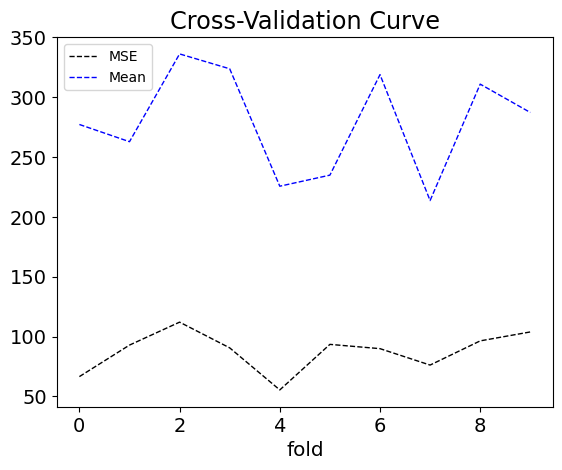

In [31]:
errors = cross_validate(concrete_dataset, 9, 8)
plot_cv(errors)

# Discussion:
The above graph indicates that kNN performs better as a predictor of concrete strength than just using the mean of the training set. Cross-validation sows that is is true over a random subsets of the input data.

## Problem 3: Hyperparameter Tuning

Tune the value of k.

<a id="get_best_k"></a>
## get_best_k

*`get_best_k` Given a dictionary mapping neighbors (k) to a list of errors, find the k with the lowest average error and standard deviation.* **Uses** [evaluate](#evaluate)

* **errors** Dict[int, List[float]]: dictionary mapping neighbors (k) to a list of error values


**returns** Tuple[int, float, float] - tuple containing the number of neighbors, average error and standard deviation of the best performing k

In [32]:
def get_best_k(errors: Dict[int, List[float]]) -> Tuple[int, float, float]:
    min_k, min_error, min_stddev = 0, inf, 0.0
    for k, es in errors.items():
        es = [i for i in es if i is not None]
        if not len(es):
            continue
        average_error = sum(es) / len(es)
        stddev_error = sqrt(sum((x - average_error) ** 2 for x in es) / len(es))
        if average_error < min_error:
            min_error, min_stddev, min_k = average_error, stddev_error, k
    return min_k, min_error, min_stddev

In [ ]:
errors = {0: [0.8, 0.8, 0.8], 1: [0.6, 0.6, 0.6], 2: [0.4, 0.4, 0.4]}
best_k, min_error, min_stddev = get_best_k(errors)
assert best_k == 2 and round(min_error, 2) == 0.4 and round(min_stddev, 3) == 0.00  # test 1 - k=2 has lowest average error

errors = {0: [], 1: [], 2: []}
best_k, min_error, min_stddev = get_best_k(errors)
assert best_k == 0  # test 2 - all empty lists

errors = {0: [0.1]}
best_k, min_error, min_stddev = get_best_k(errors)
assert best_k == 0 and round(min_error, 2) == 0.1 and min_stddev == 0.0  # test 3 - single k 

<a id="hyperparameter_tuning"></a>
## hyperparameter_tuning

*`hyperparameter_tuning` Given a list of data rows, the position of the label value in the row the upper and lower range of k values to consider, the number of folds, and a normalization function, perform 10-fold cross validation over the range of k values and return a tuple with the k value, MSE and stddev that minimizes the error, as well as a dictionary mapping each k value to a list with the MSE for each fold.* **Uses** [evaluate](#evaluate)

* **dataset** List[List[float]]: list of rows each of which is a list of features values 
* **k** int: number of neighbors to include in prediction
* **label_idx** int: label position in feature list
* **n_folds** int: number of folds to cross validate on


**returns** Tuple[Tuple[int, float, float], Dict[int, List[float]]] - a tuple holding two values, one, a tuple with the k value, MSE and stddev that minimizes the error, and second, a dictionary mapping each k value to a list with the MSE for each fold.

In [34]:
def hyperparameter_tuning(
    dataset: List[List[float]], label_idx: int, low_k: int = 2, high_k: int = 23, n_folds: int = 10, normalize: Callable | None = None
) -> Tuple[Tuple[int, float, float], Dict[int, List[float]]] | None:
    
    if not len(dataset):
        return None
    ks = range(low_k, high_k, 2)
    errors = {k: [] for k in ks}
    folds = create_folds(dataset, n_folds)

    for i in range(n_folds):
        train, test = create_train_test(folds, i)
        if normalize is not None:
            train, test = normalize(train, test, label_idx)
        for k in ks:
            error = evaluate(train, test, k, label_idx)
            errors[k].append(error)

    min_k, min_error, min_stddev = get_best_k(errors)
    return (min_k, min_error, min_stddev), errors

In [ ]:
data = [[0.23, 0.81, 0.18], [0.42, 0.78, 0.33], [0.64, 0.23, 0.14], [0.87, 0.19, 0.17], [0.76, 0.43, 0.32]]

result1 = hyperparameter_tuning(data, 2, 2, 6,2)
assert result1 is not None and result1[0][0] == 2 # test 1 - returns best k


data = []

result2 = hyperparameter_tuning(data, 2, 2, 6,2)
assert result2 is None # test 2 - empty data returns None


data = [[0.23, 0.81, 0.18], [], [0.64, 0.23, 0.14], [0.87, 0.19, 0.17], [0.76, 0.43, 0.32]]

result3 = hyperparameter_tuning(data, 2, 2, 6,2)
assert result3 is not None and result3 != result1 # test 3 - Missing row is skipped

<a id="plot_hyperparameter_tuning"></a>
## plot_hyperparameter_tuning

*`plot_hyperparameter_tuning` Given a dictionary mapping each k value to the MSE for each cross-validation fold, plot the average error and standard deviation for each k value.*

* **errors** Dict[int, List[float]]: dictionary mapping each k value to the MSE for each cross-validation fold

**returns** 

In [36]:
def plot_hyperparameter_tuning(errors: Dict[int, List[float]]):
    xs = []
    means = []
    stddevs = []
    for k, es in errors.items():
        if not len(es):
            continue
        average_error = sum(es) / len(es)
        stddev_error = sqrt(sum((x - average_error) ** 2 for x in es) / len(es))
        xs.append(k)
        means.append(average_error)
        stddevs.append(stddev_error)

    plt.figure()
    plt.title("Hyperparameter Tuning", size="xx-large")
    plt.xlabel("K", size="x-large")
    plt.ylabel("Error", size="x-large")
    plt.errorbar(xs, means, stddevs, markersize=0, linewidth=1, label="MSE")
    plt.tick_params(axis="both", which="major", labelsize=14)
    plt.legend()
    plt.show()

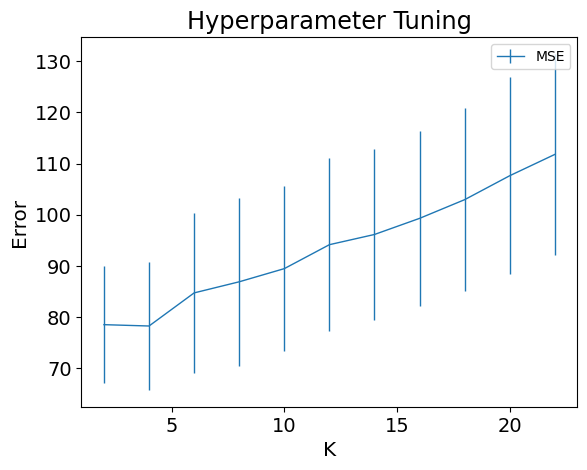


Best K: 4 | Error 78.256 (stddev: 12.492)


In [ ]:
(best_k, min_error, min_stddev), errors = hyperparameter_tuning(concrete_dataset, 8) # type: ignore
plot_hyperparameter_tuning(errors)
print(f"\nBest K: {best_k} | Error {min_error:.3f} (stddev: {min_stddev:.3f})")

## Problem 4: Generalization Error

Analyze and discuss the generalization error of your model with the value of k from Problem 3.

# Discussion:
The Hyperparameter tuning plot above indicates that the value of k does drastically change the performance of the model. When k<4, the plot shows that the error (MSE) is high, as to few neighbors are considered. As k rises above 4, to many neighbors are considered in the search degrading performance. The use of cross-validation helps confirm that these results as the MSE is averaged over 10 fold cv runs. 

## Problem 5: Choose your own adventure

You have two options for the next part:

1. You can implement mean normalization (also called "z-score standardization") of the *features*; **do not** normalize the target, y. See if this improves the generalization error of your model (middle).

2. You can implement *learning curves* to see if more data would likely improve your model (easiest).


<a id="mean_normalization"></a>
## mean_normalization

*`mean_normalization` Given a test and training set of feature rows, and the position of the label feature, compute the mean and standard deviation for each feature and normalize each value by: $$x = \frac{x_{j,i} - u_i}{\sigma_i}$$ for Each value ($x$), mean ($u$) and standard deviation ($\sigma$) in column $i$ and each row $j$*

* **errors** Dict[int, List[float]]: dictionary mapping each k value to the MSE for each cross-validation fold

**returns** Tuple[List[List[float]], List[List[float]]] - normalized train and test set

In [38]:
def mean_normalization(train: List[List[float]], test: List[List[float]], label_idx: int) -> Tuple[List[List[float]], List[List[float]]]:
    normalized_train = deepcopy(train)
    normalized_test = deepcopy(test)
    cols = len(train[0])

    for col in range(cols):
        if col == label_idx:
            continue

        vals = [example[col] for example in train]
        mean = sum(vals) / len(vals)
        stddev = sqrt(sum((x - mean) ** 2 for x in vals) / len(vals))

        for row in range(len(train)):
            normalized_train[row][col] = (train[row][col] - mean) / stddev

        for row in range(len(test)):
            normalized_test[row][col] = (test[row][col] - mean) / stddev

    return normalized_train, normalized_test

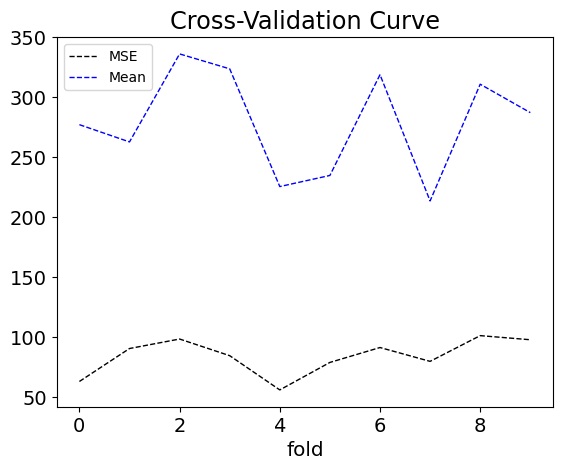

In [39]:
errors = cross_validate(concrete_dataset, 9, 8, normalize=mean_normalization)
plot_cv(errors)

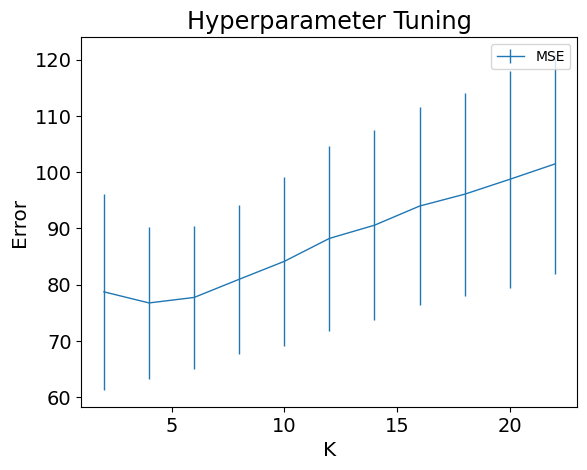


Best K: 4 | Error 76.749 (stddev: 13.503)


In [ ]:
(best_k, min_error, min_stddev), errors = hyperparameter_tuning(concrete_dataset, 8, normalize=mean_normalization) # type: ignore
plot_hyperparameter_tuning(errors)
print(f"\nBest K: {best_k} | Error {min_error:.3f} (stddev: {min_stddev:.3f})")

# Discussion:
It seems that mean-normalization had little effect on the kNN model. This is most likely due to the uniformity of units in the dataset (mg), except for days. 

<a id="learning_curve"></a>
## learning_curve

*`learning_curve` Given a list of feature rows, k neighbors to consider, the position of the label value in the feature row, the number of folds and the size of increments to make in training size, generate a learning curve by performing n-fold cross validation with incrementally bigger training sets. The training error is calculated by running the kNN model on the training set against the training set, while the validation error evaluates the MSE of the kNN trained on the training data and queried on each row in the test set. This function returns the average training error and average validation error.* **Uses** [evaluate](#evaluate)

* **dataset** List[List[float]]: list of rows each of which is a list of features values 
* **k** int: number of neighbors to include in prediction
* **label_idx** int: label position in feature list
* **n_folds** int: number of folds to cross validate on 
* **increments** int: number of increments to make in the training subset size


**returns** Tuple[List[Tuple[int, float]], List[Tuple[int, float]]] - Tuple with list of tuples holding the training set size and the training error and a list of tuples holding the training set size and the validation error

In [41]:
def learning_curve(dataset: List[List[float]], k: int, label_idx: int, n_folds: int = 10, increments: int = 10) -> Tuple[List[Tuple[int, float]], List[Tuple[int, float]]]:
    sizes = list(range(5, 100 + increments, increments))
    train_errors = {p: [] for p in sizes}
    validation_errors = {p: [] for p in sizes}

    folds = create_folds(dataset, n_folds)
    for i in range(n_folds):
        all_train, test = create_train_test(folds, i)
        for perc in sizes:
            training_size = int(len(all_train) * (perc / 100))
            sub_train = all_train[:training_size]
            train_mse = evaluate(sub_train, sub_train, k, label_idx)
            validation_mse = evaluate(sub_train, test, k, label_idx)
            train_errors[perc].append(train_mse)
            validation_errors[perc].append(validation_mse)

    avrg_train_errors = [(p, sum(errors) / len(errors)) for p, errors in train_errors.items()]
    avrg_validation_errors = [(p, sum(errors) / len(errors)) for p, errors in validation_errors.items()]
    return avrg_train_errors, avrg_validation_errors

<a id="plot_learning_curve"></a>
## plot_learning_curve

*`plot_learning_curve` Given a list of tuples holding the training set size and its training error and a list of tuples holding the training set size and the corresponding validation error, plot the training error and validation error.* 

* **train_errors** List[Tuple[int, float]]: list of tuples holding the training set size and the training error 
* **validation_errors** List[Tuple[int, float]]: list of tuples holding the training set size and the validation error 

**returns** 

In [42]:
def plot_learning_curve(train_errors: List[Tuple[int, float]], validation_errors: List[Tuple[int, float]]):
    train_xs = [i[0] for i in train_errors]
    train_vals = [i[1] for i in train_errors]

    validation_xs = [i[0] for i in validation_errors]
    validation_vals = [i[1] for i in validation_errors]

    plt.figure()
    plt.title("Learning Curve", size="xx-large")
    plt.xlabel("Training Size (%)", size="x-large")
    plt.ylabel("Error (MSE)", size="x-large")
    plt.plot(train_xs, train_vals, "k^--", markersize=0, linewidth=1, label="Training MSE")
    plt.plot(validation_xs, validation_vals, "b^--", markersize=0, linewidth=1, label="Validation MSE")
    plt.tick_params(axis="both", which="major", labelsize=14)
    plt.legend()
    plt.show()

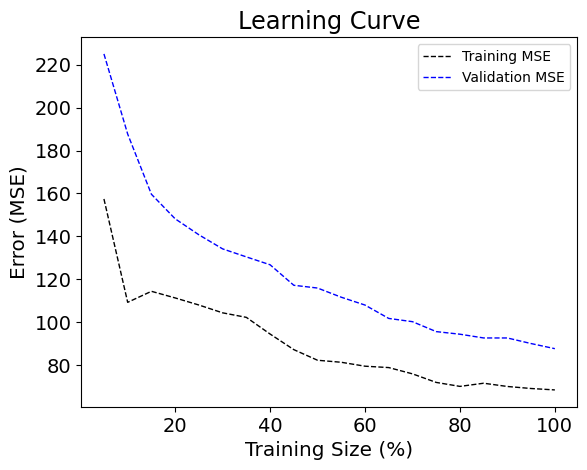

In [43]:
# # supporting code and discussion
increments = 5
train_errors, validation_errors = learning_curve(concrete_dataset, 9, 8, 10, increments)
plot_learning_curve(train_errors, validation_errors)

### Discussion: 
The learning curve suggest that more data would help improve the model, as the training error has not converged with the validation error. 

## Before You Submit...

1. Did you provide output exactly as requested?
2. Did you re-execute the entire notebook? ("Restart Kernel and Rull All Cells...")
3. If you did not complete the assignment or had difficulty please explain what gave you the most difficulty in the Markdown cell below.
4. Did you change the name of the file to `jhed_id.ipynb`?

Do not submit any other files.